In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
import sys; sys.path.append("../utils")
from fft_sup_imports import * 
%matplotlib inline
update_rc_params('paper')

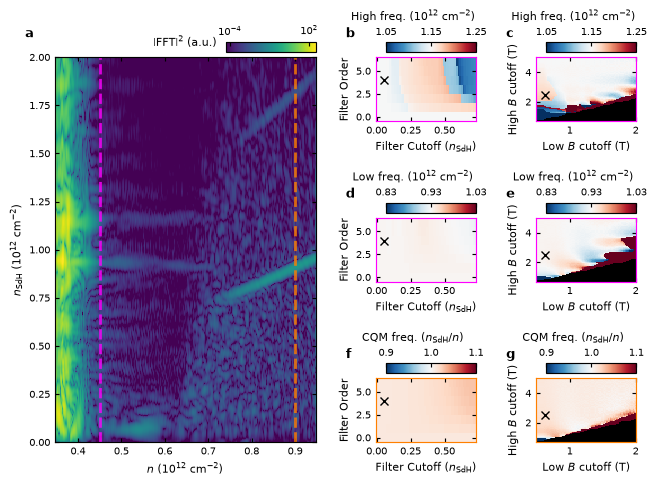

In [2]:
fig = plt.figure(figsize=(7.5, 5.0))
gs = GridSpec(3, 4,  wspace=0.6, hspace=1.5)
ax_high = [plt.subplot(gs[0,i+2]) for i in range(2)]
ax_low = [plt.subplot(gs[1,i+2]) for i in range(2)]
ax_qm = [plt.subplot(gs[2,i+2]) for i in range(2)]
ax_overview = plt.subplot(gs[:, :2])

density_targets = [0.45, 0.9] 
density_colors = ['#FF00FF', '#FF8000']
density_axes = [[ax_high, ax_low], [ax_qm]]

analyzer = Lf_analysis(1840, contact=2)
label_spacer = 0.04
letters = list(map(chr, range(97, 97+26)))

### OVERIVIEW
ax = ax_overview
pos = ax.get_position()
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, letters[0], fontweight='bold')


plot, linecuts_out = analyzer.plot_fft_invcm(fig, ax, norm_psd,
    bg_method=detrend_butterworth,                         
    bg_method_params={'cutoff': None, 'order': 4}, # Cutoff = None --> 4 periods
    padding = 8, 
    blims=(0.62, 4.98),
    target_densities=density_targets
)

cb_width = 0.12
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])
cb = plt.colorbar(plot, cax=cax, ticks=[1e-4, 1e2], \
                 orientation='horizontal', shrink=0.3, pad=0.01, aspect=5)
cb.ax.xaxis.set_ticks_position('top')
cb.ax.set_xlabel(r'$\left|\mathrm{FFT}\right|^2$ (a.u.)', labelpad=-12, x=-0.45)
ax.vlines(density_targets, 0, 2, density_colors, linestyle='dashed', alpha=0.8, lw=2)

# For determining target freqs
# for psd, freq in linecuts_out:
#     peaks, _ = find_peaks(psd, prominence=1e-4)
#     flims = (0.8, 1.2)
#     peaks = peaks[(flims[0] < freq[peaks]) & (freq[peaks] < flims[1])]
    
#     peaks_sorted = peaks[np.argsort(-1*psd[peaks])]

typical_filter = [0.288 * 8/(1e16*phi0), 4]
typical_field = [0.62, 2.49]

# Plot the maps in field and cutoff
target_freqs_invcm2 = [
    [1.15, 0.93],
    [0.905]
]
cb_width = 0.12

for i, axes in enumerate(density_axes):
    for j, ax in enumerate(np.ravel(axes)):
        for spine in ax.spines.values():
            spine.set_edgecolor(density_colors[i])    

        pos = ax.get_position()
        letter_idx = 4*i+j + 1 
        fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, letters[letter_idx], fontweight='bold')

        target_freq_invcm2 = target_freqs_invcm2[i][j//2] 
        freq_eps = 0.1
        target_freq_invcm2 = np.round(target_freq_invcm2, 2)
        target_freq_dimensionless = target_freq_invcm2/density_targets[i]
        target_freq_dimensionless = np.round(target_freq_dimensionless, 2)

        if i >= 1: 
            norm = colors.Normalize(target_freq_dimensionless-freq_eps, target_freq_dimensionless+freq_eps)
        else:
            norm = colors.Normalize(target_freq_invcm2-freq_eps, target_freq_invcm2+freq_eps)
        if j % 2 == 0:
            plot = analyzer.plot_bw_filter_effect(
                fig, ax, norm, 
                padding = 8,
                target_density = density_targets[i], 
                target_freq = target_freq_dimensionless,
                n_filters=60,
                plot_dimensionless=i >= 1 # True for QM 
            )
            ax.plot(*typical_filter, 'x', color='k')
        else: 
            plot = analyzer.plot_blim_effect(
                fig, ax, norm, 
                bg_method=detrend_butterworth,                         
                bg_method_params={'cutoff': None, 'order': 4}, # Cutoff = None --> 4 periods
                padding = 8,
                blo_min = 0.5,
                bhi_max = 5.0,
                target_density = density_targets[i] , 
                target_freq =target_freq_dimensionless,
                n_B_lims=80,
                plot_dimensionless=i >= 1 
            )
            ax.plot(*typical_field, 'x', color='k')
        
        cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])
        if i >= 1:
            cb = plt.colorbar(plot, cax=cax, ticks=target_freq_dimensionless + np.array([-freq_eps, 0, freq_eps]), \
                            orientation='horizontal', shrink=0.3, pad=0.01, aspect=5)
            cb.ax.set_xlabel(r'CQM freq. ($n_{\mathrm{SdH}}/n$)', labelpad=5, x=0.3)
        else:
            cb = plt.colorbar(plot, cax=cax, ticks=target_freq_invcm2 + np.array([-freq_eps, 0, freq_eps]), \
                            orientation='horizontal', shrink=0.3, pad=0.01, aspect=5)
            unit_str = r"$10^{12}$ cm$^{-2}$"
            cb.ax.set_xlabel(rf"{'Low' if j // 2 else 'High'} freq. ({unit_str})", labelpad=5, x=0.3)
        cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
        cb.ax.xaxis.set_label_position('top')
            
        
plt.savefig('figS_FFT_hightone_filters.pdf', dpi=600, bbox_inches='tight',
            pad_inches=0.02, transparent=False)